In [1]:
# ============================================================
# Get Fit with Drishti
# Phase 4 Part A: Ideal Client Profile
# Step 1: Create Ideal Client Flag
# ============================================================

# Import required libraries
import pandas as pd
import numpy as np

# Load the cleaned dataset from the cleaned data folder
df = pd.read_csv("../02_cleaned_data/Drishti_Clean_Data.csv")

# Check basic dataset shape
print("Dataset shape:", df.shape)

# Create Ideal Client flag
# Ideal Client means:
# 1. Completed the program
# 2. Achieved the goal
# 3. Had check-in rate of 80% or higher
df["Ideal_Client"] = np.where(
    (df["Status"] == "Completed") &
    (df["Goal_Achieved"] == "Yes") &
    (df["Checkin_Rate_Pct"] >= 80),
    1,
    0
)

# Count ideal clients vs other clients
ideal_summary = df["Ideal_Client"].value_counts().rename(index={
    1: "Ideal Clients",
    0: "Other Clients"
})

# Calculate percentage
ideal_percentage = df["Ideal_Client"].value_counts(normalize=True).rename(index={
    1: "Ideal Clients",
    0: "Other Clients"
}) * 100

# Combine count and percentage into one table
ideal_client_summary = pd.DataFrame({
    "Client_Count": ideal_summary,
    "Percentage": ideal_percentage.round(2)
})

# Display summary
ideal_client_summary

Dataset shape: (3000, 40)


,Client_Count,Percentage
Ideal_Client,,
Other Clients,1856,61.87
Ideal Clients,1144,38.13


In [3]:
# ============================================================
# Phase 4 Part A
# Step 2: Compare Ideal Clients vs Other Clients - Categorical Columns
# Corrected Version
# ============================================================

# Select categorical columns that are useful for Ideal Client Profile analysis
categorical_cols = [
    "Gender",
    "Country",
    "Diet_Type",
    "Goal_Type",
    "Lead_Source",
    "Health_Condition",
    "Daily_Schedule",
    "Exercise_History",
    "Daily_Comm_Frequency",
    "Motivation_Level_Start",
    "Progress_Photos_Shared",
    "Second_Round",
    "Was_Referred",
    "Ever_Engaged"
]

# Keep only columns that actually exist in the dataset
categorical_cols = [col for col in categorical_cols if col in df.columns]

# Create an empty list to store comparison results
comparison_results = []

# Loop through every categorical column
for col in categorical_cols:
    
    # Create a copy with only the current column and Ideal_Client flag
    temp_df = df[[col, "Ideal_Client"]].copy()
    
    # Replace missing values with "Missing"
    temp_df[col] = temp_df[col].fillna("Missing")
    
    # Create percentage table using crosstab
    # This calculates what percentage of Ideal Clients and Other Clients fall into each category
    pct_table = pd.crosstab(
        temp_df[col],
        temp_df["Ideal_Client"],
        normalize="columns"
    ) * 100
    
    # Rename columns clearly
    pct_table = pct_table.rename(columns={
        0: "Other_Client_Pct",
        1: "Ideal_Client_Pct"
    })
    
    # Make sure both columns exist, even if one group is missing
    if "Other_Client_Pct" not in pct_table.columns:
        pct_table["Other_Client_Pct"] = 0
        
    if "Ideal_Client_Pct" not in pct_table.columns:
        pct_table["Ideal_Client_Pct"] = 0
    
    # Reset index so category becomes a normal column
    pct_table = pct_table.reset_index()
    
    # Rename the category column
    pct_table = pct_table.rename(columns={col: "Category"})
    
    # Add dimension name
    pct_table["Dimension"] = col
    
    # Calculate percentage point difference
    pct_table["Difference_Points"] = (
        pct_table["Ideal_Client_Pct"] - pct_table["Other_Client_Pct"]
    )
    
    # Calculate how many times more likely ideal clients are to have this characteristic
    pct_table["Times_More_Likely"] = np.where(
        pct_table["Other_Client_Pct"] > 0,
        pct_table["Ideal_Client_Pct"] / pct_table["Other_Client_Pct"],
        np.nan
    )
    
    # Keep columns in clean order
    pct_table = pct_table[
        [
            "Dimension",
            "Category",
            "Ideal_Client_Pct",
            "Other_Client_Pct",
            "Difference_Points",
            "Times_More_Likely"
        ]
    ]
    
    # Store result
    comparison_results.append(pct_table)

# Combine all comparison tables
categorical_comparison = pd.concat(comparison_results, ignore_index=True)

# Round numbers
categorical_comparison["Ideal_Client_Pct"] = categorical_comparison["Ideal_Client_Pct"].round(2)
categorical_comparison["Other_Client_Pct"] = categorical_comparison["Other_Client_Pct"].round(2)
categorical_comparison["Difference_Points"] = categorical_comparison["Difference_Points"].round(2)
categorical_comparison["Times_More_Likely"] = categorical_comparison["Times_More_Likely"].round(2)

# Sort by strongest positive difference
categorical_comparison_sorted = categorical_comparison.sort_values(
    by="Difference_Points",
    ascending=False
)

# Show top 25 strongest ideal-client characteristics
categorical_comparison_sorted.head(25)

Ideal_Client,Dimension,Category,Ideal_Client_Pct,Other_Client_Pct,Difference_Points,Times_More_Likely
41,Progress_Photos_Shared,Yes,81.38,58.73,22.65,1.39
33,Daily_Comm_Frequency,Daily,71.24,59.00,12.24,1.21
42,Second_Round,No,91.61,82.11,9.50,1.12
47,Ever_Engaged,True,100.00,92.83,7.17,1.08
12,Goal_Type,Body Transformation,33.22,30.01,3.21,1.11
37,Motivation_Level_Start,High,59.79,57.49,2.30,1.04
32,Exercise_History,Regular,20.28,18.37,1.91,1.10
26,Daily_Schedule,Flexible,26.49,24.62,1.86,1.08
45,Was_Referred,True,26.75,25.11,1.64,1.07
17,Lead_Source,Referral,26.75,25.11,1.64,1.07


In [4]:
# ============================================================
# Phase 4 Part A
# Step 3: Compare Ideal Clients vs Other Clients - Numeric Columns
# ============================================================

# Select numeric columns that are useful for Ideal Client Profile analysis
numeric_cols = [
    "Age",
    "Goal_Gap_kg",
    "Payment_Speed_Days",
    "Days_To_First_Engagement",
    "Checkin_Rate_Pct",
    "Weekly_Checkins_Completed",
    "Program_Duration_Days",
    "Revenue_USD"
]

# Keep only columns that actually exist in the dataset
numeric_cols = [col for col in numeric_cols if col in df.columns]

# Create a copy for numeric comparison
numeric_df = df[numeric_cols + ["Ideal_Client"]].copy()

# Convert Days_To_First_Engagement to numeric if it is not already numeric
# Any non-numeric values will become NaN
if "Days_To_First_Engagement" in numeric_df.columns:
    numeric_df["Days_To_First_Engagement"] = pd.to_numeric(
        numeric_df["Days_To_First_Engagement"],
        errors="coerce"
    )

# Create numeric comparison table
numeric_comparison = (
    numeric_df
    .groupby("Ideal_Client")[numeric_cols]
    .mean()
    .T
    .reset_index()
)

# Rename columns clearly
numeric_comparison = numeric_comparison.rename(columns={
    "index": "Metric",
    0: "Other_Client_Avg",
    1: "Ideal_Client_Avg"
})

# Calculate difference
numeric_comparison["Difference"] = (
    numeric_comparison["Ideal_Client_Avg"] - numeric_comparison["Other_Client_Avg"]
)

# Calculate percentage difference
numeric_comparison["Pct_Difference"] = np.where(
    numeric_comparison["Other_Client_Avg"] != 0,
    (numeric_comparison["Difference"] / numeric_comparison["Other_Client_Avg"]) * 100,
    np.nan
)

# Round results
numeric_comparison["Other_Client_Avg"] = numeric_comparison["Other_Client_Avg"].round(2)
numeric_comparison["Ideal_Client_Avg"] = numeric_comparison["Ideal_Client_Avg"].round(2)
numeric_comparison["Difference"] = numeric_comparison["Difference"].round(2)
numeric_comparison["Pct_Difference"] = numeric_comparison["Pct_Difference"].round(2)

# Display numeric comparison
numeric_comparison

Ideal_Client,Metric,Other_Client_Avg,Ideal_Client_Avg,Difference,Pct_Difference
0,Age,32.79,33.32,0.53,1.63
1,Goal_Gap_kg,13.14,12.47,-0.67,-5.07
2,Payment_Speed_Days,3.07,2.74,-0.33,-10.59
3,Days_To_First_Engagement,73.44,1.66,-71.78,-97.74
4,Checkin_Rate_Pct,63.94,92.73,28.78,45.01
5,Weekly_Checkins_Completed,8.95,12.98,4.03,45.02
6,Program_Duration_Days,77.82,100.00,22.18,28.50
7,Revenue_USD,285.78,285.64,-0.13,-0.05


In [5]:
# ============================================================
# Phase 4 Part A
# Step 4: Generate Ideal Client Insight Sentences
# ============================================================

# Create a copy of the categorical comparison table
insight_df = categorical_comparison_sorted.copy()

# Keep only characteristics where ideal clients are more likely than other clients
# We focus on meaningful differences only
insight_df = insight_df[
    (insight_df["Difference_Points"] > 1) &
    (insight_df["Times_More_Likely"] > 1)
].copy()

# Sort by strongest percentage point difference
insight_df = insight_df.sort_values(by="Difference_Points", ascending=False)

# Keep top 15 strongest insights
top_insights = insight_df.head(15).copy()

# Create readable business insight sentences
top_insights["Insight_Sentence"] = top_insights.apply(
    lambda row: (
        f"Ideal clients are {row['Times_More_Likely']} times more likely to be "
        f"{row['Category']} in {row['Dimension'].replace('_', ' ')} "
        f"({row['Ideal_Client_Pct']}% of ideal clients vs {row['Other_Client_Pct']}% of other clients)."
    ),
    axis=1
)

# Display only the clean insight sentences
top_insights[["Dimension", "Category", "Insight_Sentence"]]

Ideal_Client,Dimension,Category,Insight_Sentence
41,Progress_Photos_Shared,Yes,Ideal clients are 1.39 times more likely to be...
33,Daily_Comm_Frequency,Daily,Ideal clients are 1.21 times more likely to be...
42,Second_Round,No,Ideal clients are 1.12 times more likely to be...
47,Ever_Engaged,True,Ideal clients are 1.08 times more likely to be...
12,Goal_Type,Body Transformation,Ideal clients are 1.11 times more likely to be...
37,Motivation_Level_Start,High,Ideal clients are 1.04 times more likely to be...
32,Exercise_History,Regular,Ideal clients are 1.1 times more likely to be ...
26,Daily_Schedule,Flexible,Ideal clients are 1.08 times more likely to be...
45,Was_Referred,True,Ideal clients are 1.07 times more likely to be...
17,Lead_Source,Referral,Ideal clients are 1.07 times more likely to be...


In [6]:
# ============================================================
# Phase 4 Part A
# Step 4B: Print Full Insight Sentences
# ============================================================

# Print each insight sentence fully
for sentence in top_insights["Insight_Sentence"]:
    print("- " + sentence)

- Ideal clients are 1.39 times more likely to be Yes in Progress Photos Shared (81.38% of ideal clients vs 58.73% of other clients).
- Ideal clients are 1.21 times more likely to be Daily in Daily Comm Frequency (71.24% of ideal clients vs 59.0% of other clients).
- Ideal clients are 1.12 times more likely to be No in Second Round (91.61% of ideal clients vs 82.11% of other clients).
- Ideal clients are 1.08 times more likely to be True in Ever Engaged (100.0% of ideal clients vs 92.83% of other clients).
- Ideal clients are 1.11 times more likely to be Body Transformation in Goal Type (33.22% of ideal clients vs 30.01% of other clients).
- Ideal clients are 1.04 times more likely to be High in Motivation Level Start (59.79% of ideal clients vs 57.49% of other clients).
- Ideal clients are 1.1 times more likely to be Regular in Exercise History (20.28% of ideal clients vs 18.37% of other clients).
- Ideal clients are 1.08 times more likely to be Flexible in Daily Schedule (26.49% of id

In [7]:
# ============================================================
# Phase 4 Part A
# Step 6: Save Ideal Client Analysis Tables
# ============================================================

# Import os to work with folders
import os

# Create output folder path
output_folder = "../05_outputs/phase4_ideal_client_profile"

# Create the folder if it does not already exist
os.makedirs(output_folder, exist_ok=True)

# Save ideal client summary table
ideal_client_summary.to_csv(
    f"{output_folder}/ideal_client_summary.csv",
    index=True
)

# Save full categorical comparison table
categorical_comparison_sorted.to_csv(
    f"{output_folder}/ideal_client_categorical_comparison.csv",
    index=False
)

# Save numeric comparison table
numeric_comparison.to_csv(
    f"{output_folder}/ideal_client_numeric_comparison.csv",
    index=False
)

# Save top insight sentences
top_insights.to_csv(
    f"{output_folder}/ideal_client_insight_sentences.csv",
    index=False
)

# Confirm files were saved
print("Ideal Client Profile files saved successfully!")
print("Saved folder:", output_folder)

Ideal Client Profile files saved successfully!
Saved folder: ../05_outputs/phase4_ideal_client_profile


In [8]:
# ============================================================
# Phase 4 Part B
# Step 1: Prepare Data for K-Means Client Segmentation
# ============================================================

# Import required libraries for clustering
from sklearn.preprocessing import StandardScaler

# Create a copy of the main dataframe for segmentation
seg_df = df.copy()

# ------------------------------------------------------------
# Convert Days_To_First_Engagement to numeric
# ------------------------------------------------------------

# If there are any text values, convert them into numbers
# Invalid values become NaN
seg_df["Days_To_First_Engagement"] = pd.to_numeric(
    seg_df["Days_To_First_Engagement"],
    errors="coerce"
)

# Exclude clients coded as 999 because 999 means "never engaged"
# K-Means should not treat 999 as a real number of days
seg_df_for_clustering = seg_df[seg_df["Days_To_First_Engagement"] != 999].copy()

# ------------------------------------------------------------
# Encode Motivation_Level_Start
# ------------------------------------------------------------

# Convert motivation levels into numeric values
motivation_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

seg_df_for_clustering["Motivation_Level_Encoded"] = (
    seg_df_for_clustering["Motivation_Level_Start"].map(motivation_map)
)

# ------------------------------------------------------------
# Convert Ever_Engaged and Was_Referred to 0/1
# ------------------------------------------------------------

# Convert boolean True/False columns into integers if they exist
seg_df_for_clustering["Ever_Engaged_Num"] = seg_df_for_clustering["Ever_Engaged"].astype(int)
seg_df_for_clustering["Was_Referred_Num"] = seg_df_for_clustering["Was_Referred"].astype(int)

# ------------------------------------------------------------
# Select clustering features
# ------------------------------------------------------------

clustering_features = [
    "Age",
    "Goal_Gap_kg",
    "Checkin_Rate_Pct",
    "Program_Duration_Days",
    "Payment_Speed_Days",
    "Days_To_First_Engagement",
    "Motivation_Level_Encoded",
    "Ever_Engaged_Num",
    "Was_Referred_Num"
]

# Create final clustering input table
cluster_input = seg_df_for_clustering[clustering_features].copy()

# ------------------------------------------------------------
# Handle any remaining missing values
# ------------------------------------------------------------

# Fill remaining missing values with the median of each column
cluster_input = cluster_input.fillna(cluster_input.median())

# ------------------------------------------------------------
# Scale features
# ------------------------------------------------------------

# K-Means needs scaled data because columns are in different units
scaler = StandardScaler()

# Fit scaler and transform the clustering input data
cluster_scaled = scaler.fit_transform(cluster_input)

# Convert scaled array back into a dataframe for easier checking
cluster_scaled_df = pd.DataFrame(
    cluster_scaled,
    columns=clustering_features,
    index=cluster_input.index
)

# ------------------------------------------------------------
# Check final prepared clustering data
# ------------------------------------------------------------

print("Original dataset rows:", df.shape[0])
print("Rows used for clustering:", cluster_input.shape[0])
print("Rows excluded because Days_To_First_Engagement = 999:", df.shape[0] - cluster_input.shape[0])
print("Number of clustering features:", cluster_input.shape[1])
print("Remaining missing values:", cluster_input.isnull().sum().sum())

# Display first few rows of prepared input
cluster_input.head()

Original dataset rows: 3000
Rows used for clustering: 2867
Rows excluded because Days_To_First_Engagement = 999: 133
Number of clustering features: 9
Remaining missing values: 0


,Age,Goal_Gap_kg,Checkin_Rate_Pct,Program_Duration_Days,Payment_Speed_Days,Days_To_First_Engagement,Motivation_Level_Encoded,Ever_Engaged_Num,Was_Referred_Num
0,24,9,100.0,100,2,3,2,1,0
2,19,18,78.6,100,7,3,2,1,0
3,22,24,100.0,100,1,5,2,1,0
4,31,25,0.0,4,1,0,2,1,0
5,30,22,100.0,100,1,1,2,1,0


In [9]:
# ============================================================
# Phase 4 Part B
# Step 2: Elbow Curve and Silhouette Score
# ============================================================

# Import clustering and evaluation libraries
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Import plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create empty lists to store results
k_values = range(2, 11)
inertia_scores = []
silhouette_scores = []

# Loop through k values from 2 to 10
for k in k_values:
    
    # Create K-Means model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    # Fit model and assign cluster labels
    cluster_labels = kmeans.fit_predict(cluster_scaled)
    
    # Store inertia score for elbow curve
    inertia_scores.append(kmeans.inertia_)
    
    # Store silhouette score
    silhouette_scores.append(
        silhouette_score(cluster_scaled, cluster_labels)
    )

# Create results table
k_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_scores,
    "Silhouette_Score": silhouette_scores
})

# Display results table
k_results


,K,Inertia,Silhouette_Score
0,2,17633.868211,0.366888
1,3,15123.406597,0.231796
2,4,13758.940552,0.186346
3,5,12539.542391,0.190073
4,6,11739.275866,0.181980
5,7,10911.516129,0.193944
6,8,10456.697718,0.178957
7,9,9813.923319,0.184376
8,10,9323.987214,0.195200


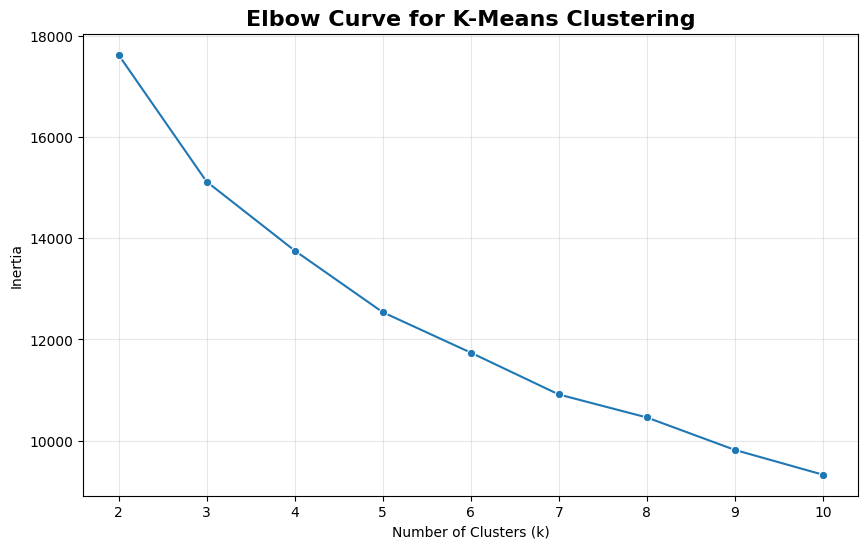

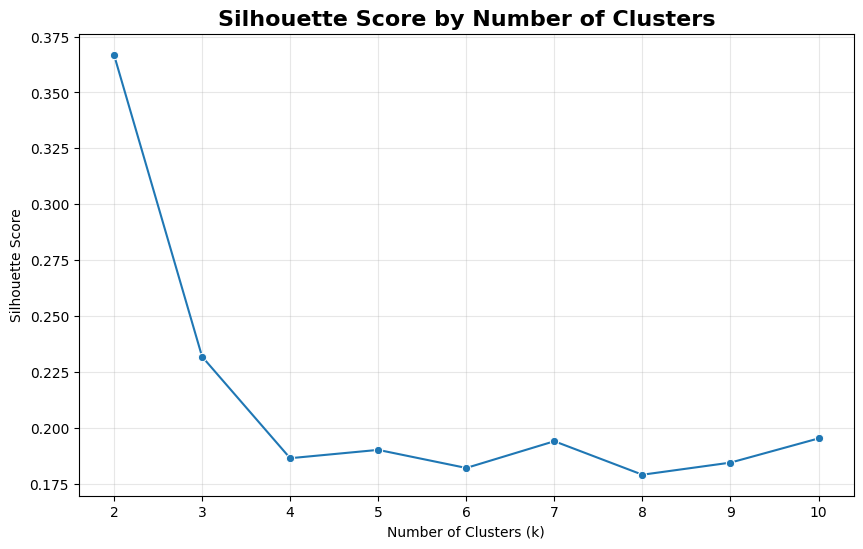

In [10]:
# ============================================================
# Phase 4 Part B
# Step 2B: Visualize Elbow Curve and Silhouette Scores
# ============================================================

# Create elbow curve
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=k_results,
    x="K",
    y="Inertia",
    marker="o"
)

plt.title("Elbow Curve for K-Means Clustering", fontsize=16, fontweight="bold")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()


# Create silhouette score chart
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=k_results,
    x="K",
    y="Silhouette_Score",
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters", fontsize=16, fontweight="bold")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# ============================================================
# Phase 4 Part B
# Step 3: Run K-Means with k = 4
# ============================================================

# Create final K-Means model with 4 clusters
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Fit the model and assign cluster labels to the clustering dataset
seg_df_for_clustering["Cluster"] = kmeans_4.fit_predict(cluster_scaled)

# Also add cluster labels to the scaled dataframe
cluster_scaled_df["Cluster"] = seg_df_for_clustering["Cluster"]

# Check how many clients are in each cluster
cluster_counts = (
    seg_df_for_clustering["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

# Rename columns clearly
cluster_counts.columns = ["Cluster", "Client_Count"]

# Calculate percentage of clients in each cluster
cluster_counts["Percentage"] = (
    cluster_counts["Client_Count"] / cluster_counts["Client_Count"].sum() * 100
).round(2)

# Display cluster size table
cluster_counts

,Cluster,Client_Count,Percentage
0,0,700,24.42
1,1,429,14.96
2,2,1079,37.64
3,3,659,22.99


In [12]:
# ============================================================
# Phase 4 Part B
# Step 4: Profile Each Cluster
# ============================================================

# ------------------------------------------------------------
# Create helper columns for outcome rates
# ------------------------------------------------------------

# Completed program flag
seg_df_for_clustering["Completed_Flag"] = np.where(
    seg_df_for_clustering["Status"] == "Completed",
    1,
    0
)

# Goal achieved flag
seg_df_for_clustering["Goal_Achieved_Flag"] = np.where(
    seg_df_for_clustering["Goal_Achieved"] == "Yes",
    1,
    0
)

# Second round flag
seg_df_for_clustering["Second_Round_Flag"] = np.where(
    seg_df_for_clustering["Second_Round"] == "Yes",
    1,
    0
)

# Progress photos shared flag
seg_df_for_clustering["Progress_Photos_Flag"] = np.where(
    seg_df_for_clustering["Progress_Photos_Shared"] == "Yes",
    1,
    0
)

# ------------------------------------------------------------
# Create numeric cluster profile
# ------------------------------------------------------------

cluster_profile = (
    seg_df_for_clustering
    .groupby("Cluster")
    .agg(
        Client_Count=("Client_ID", "count"),
        Avg_Age=("Age", "mean"),
        Avg_Goal_Gap_kg=("Goal_Gap_kg", "mean"),
        Avg_Checkin_Rate_Pct=("Checkin_Rate_Pct", "mean"),
        Avg_Program_Duration_Days=("Program_Duration_Days", "mean"),
        Avg_Payment_Speed_Days=("Payment_Speed_Days", "mean"),
        Avg_Days_To_First_Engagement=("Days_To_First_Engagement", "mean"),
        Avg_Motivation_Level=("Motivation_Level_Encoded", "mean"),
        Engagement_Rate=("Ever_Engaged_Num", "mean"),
        Referral_Rate=("Was_Referred_Num", "mean"),
        Completion_Rate=("Completed_Flag", "mean"),
        Goal_Achievement_Rate=("Goal_Achieved_Flag", "mean"),
        Second_Round_Rate=("Second_Round_Flag", "mean"),
        Progress_Photos_Rate=("Progress_Photos_Flag", "mean")
    )
    .reset_index()
)

# ------------------------------------------------------------
# Convert rate columns from decimals to percentages
# ------------------------------------------------------------

rate_cols = [
    "Engagement_Rate",
    "Referral_Rate",
    "Completion_Rate",
    "Goal_Achievement_Rate",
    "Second_Round_Rate",
    "Progress_Photos_Rate"
]

for col in rate_cols:
    cluster_profile[col] = cluster_profile[col] * 100

# ------------------------------------------------------------
# Round all numeric columns for clean display
# ------------------------------------------------------------

cluster_profile = cluster_profile.round(2)

# Display cluster profile table
cluster_profile

,Cluster,Client_Count,Avg_Age,Avg_Goal_Gap_kg,Avg_Checkin_Rate_Pct,Avg_Program_Duration_Days,Avg_Payment_Speed_Days,Avg_Days_To_First_Engagement,Avg_Motivation_Level,Engagement_Rate,Referral_Rate,Completion_Rate,Goal_Achievement_Rate,Second_Round_Rate,Progress_Photos_Rate
0,0,700,32.51,12.53,89.13,99.92,2.86,1.60,0.77,100.0,0.00,99.71,64.71,0.00,79.14
1,1,429,32.76,14.03,17.02,33.12,3.71,2.89,1.29,100.0,18.41,0.00,0.00,27.04,10.49
2,2,1079,33.13,12.74,88.95,99.98,2.75,1.71,2.00,100.0,0.00,99.91,62.74,0.00,80.35
3,3,659,33.31,12.87,89.00,99.85,2.85,1.71,1.49,100.0,100.00,99.39,61.61,34.75,81.34


In [13]:
# ============================================================
# Phase 4 Part B
# Step 5: Name the 4 Client Personas
# ============================================================

# Create a dictionary to map cluster numbers to business persona names
cluster_name_map = {
    0: "The Strong Starters",
    1: "The Early Drop-Offs",
    2: "The Motivated Finishers",
    3: "The Loyal Referrals"
}

# Add persona names to the clustering dataframe
seg_df_for_clustering["Persona"] = seg_df_for_clustering["Cluster"].map(cluster_name_map)

# Add persona names to the cluster profile table
cluster_profile["Persona"] = cluster_profile["Cluster"].map(cluster_name_map)

# Reorder columns so Persona appears near the front
cluster_profile_named = cluster_profile[
    [
        "Cluster",
        "Persona",
        "Client_Count",
        "Avg_Age",
        "Avg_Goal_Gap_kg",
        "Avg_Checkin_Rate_Pct",
        "Avg_Program_Duration_Days",
        "Avg_Payment_Speed_Days",
        "Avg_Days_To_First_Engagement",
        "Avg_Motivation_Level",
        "Engagement_Rate",
        "Referral_Rate",
        "Completion_Rate",
        "Goal_Achievement_Rate",
        "Second_Round_Rate",
        "Progress_Photos_Rate"
    ]
]

# Display named cluster profile
cluster_profile_named

,Cluster,Persona,Client_Count,Avg_Age,Avg_Goal_Gap_kg,Avg_Checkin_Rate_Pct,Avg_Program_Duration_Days,Avg_Payment_Speed_Days,Avg_Days_To_First_Engagement,Avg_Motivation_Level,Engagement_Rate,Referral_Rate,Completion_Rate,Goal_Achievement_Rate,Second_Round_Rate,Progress_Photos_Rate
0,0,The Strong Starters,700,32.51,12.53,89.13,99.92,2.86,1.60,0.77,100.0,0.00,99.71,64.71,0.00,79.14
1,1,The Early Drop-Offs,429,32.76,14.03,17.02,33.12,3.71,2.89,1.29,100.0,18.41,0.00,0.00,27.04,10.49
2,2,The Motivated Finishers,1079,33.13,12.74,88.95,99.98,2.75,1.71,2.00,100.0,0.00,99.91,62.74,0.00,80.35
3,3,The Loyal Referrals,659,33.31,12.87,89.00,99.85,2.85,1.71,1.49,100.0,100.00,99.39,61.61,34.75,81.34


PCA 1 explains: 25.45 % of variation
PCA 2 explains: 12.96 % of variation
Total variation explained: 38.41 %


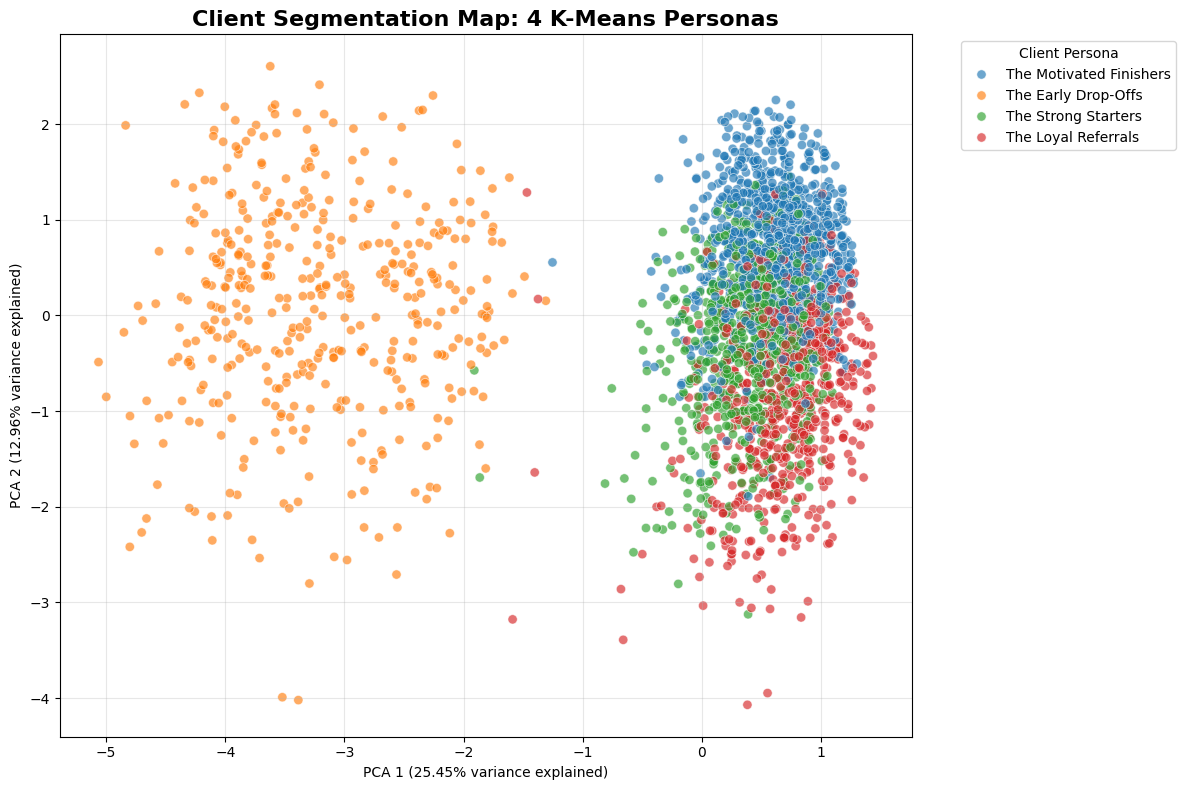

PCA scatter plot saved successfully!
Saved to: ../06_visuals/phase4_segmentation


In [14]:
# ============================================================
# Phase 4 Part B
# Step 7: PCA 2D Scatter Plot Colored by Persona
# ============================================================

# Import PCA
from sklearn.decomposition import PCA

# Import plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ------------------------------------------------------------
# Run PCA to reduce clustering features from 9 dimensions to 2
# ------------------------------------------------------------

pca = PCA(n_components=2, random_state=42)

# Fit PCA on the scaled clustering data
pca_components = pca.fit_transform(cluster_scaled)

# Create a dataframe for PCA results
pca_df = pd.DataFrame(
    pca_components,
    columns=["PCA_1", "PCA_2"],
    index=cluster_input.index
)

# Add cluster and persona labels
pca_df["Cluster"] = seg_df_for_clustering["Cluster"]
pca_df["Persona"] = seg_df_for_clustering["Persona"]

# ------------------------------------------------------------
# Check how much variation PCA explains
# ------------------------------------------------------------

explained_variance = pca.explained_variance_ratio_ * 100

print("PCA 1 explains:", round(explained_variance[0], 2), "% of variation")
print("PCA 2 explains:", round(explained_variance[1], 2), "% of variation")
print("Total variation explained:", round(explained_variance.sum(), 2), "%")

# ------------------------------------------------------------
# Create PCA scatter plot
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_df,
    x="PCA_1",
    y="PCA_2",
    hue="Persona",
    alpha=0.65,
    s=45
)

plt.title(
    "Client Segmentation Map: 4 K-Means Personas",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(f"PCA 1 ({explained_variance[0]:.2f}% variance explained)")
plt.ylabel(f"PCA 2 ({explained_variance[1]:.2f}% variance explained)")

plt.legend(
    title="Client Persona",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

# ------------------------------------------------------------
# Save chart
# ------------------------------------------------------------

output_folder = "../06_visuals/phase4_segmentation"
os.makedirs(output_folder, exist_ok=True)

plt.savefig(
    f"{output_folder}/pca_client_persona_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("PCA scatter plot saved successfully!")
print("Saved to:", output_folder)

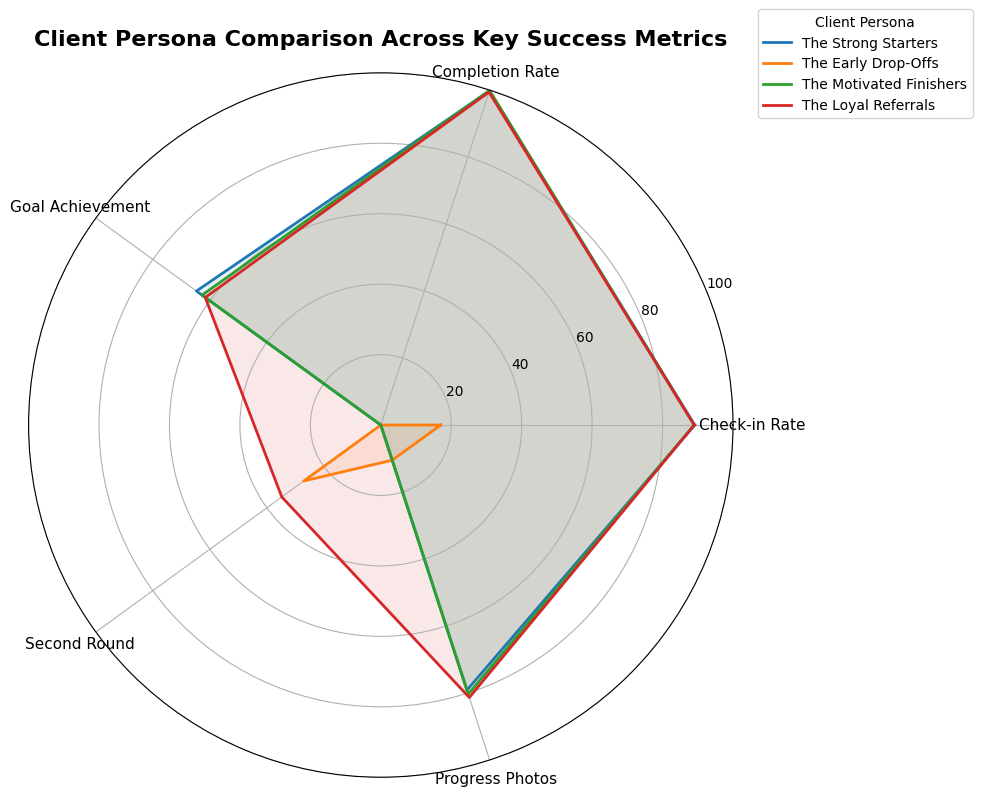

Radar chart saved successfully!
Saved to: ../06_visuals/phase4_segmentation


In [15]:
# ============================================================
# Phase 4 Part B
# Step 8: Radar Chart Comparing 4 Client Personas
# ============================================================

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# Select 5 key business dimensions for radar chart
# ------------------------------------------------------------

radar_metrics = [
    "Avg_Checkin_Rate_Pct",
    "Completion_Rate",
    "Goal_Achievement_Rate",
    "Second_Round_Rate",
    "Progress_Photos_Rate"
]

# Create a clean radar dataframe
radar_df = cluster_profile_named[
    ["Persona"] + radar_metrics
].copy()

# Rename columns for chart labels
radar_df = radar_df.rename(columns={
    "Avg_Checkin_Rate_Pct": "Check-in Rate",
    "Completion_Rate": "Completion Rate",
    "Goal_Achievement_Rate": "Goal Achievement",
    "Second_Round_Rate": "Second Round",
    "Progress_Photos_Rate": "Progress Photos"
})

# ------------------------------------------------------------
# Prepare radar chart structure
# ------------------------------------------------------------

# Get metric labels
labels = radar_df.columns[1:].tolist()

# Number of metrics
num_vars = len(labels)

# Create angles for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Close the radar chart circle
angles += angles[:1]

# ------------------------------------------------------------
# Create radar chart
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))
ax = plt.subplot(111, polar=True)

# Plot each persona
for index, row in radar_df.iterrows():
    
    # Get values for one persona
    values = row[labels].tolist()
    
    # Close the radar line
    values += values[:1]
    
    # Plot persona line
    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Persona"]
    )
    
    # Fill area lightly
    ax.fill(
        angles,
        values,
        alpha=0.10
    )

# Set radar labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)

# Set y-axis range from 0 to 100 because all metrics are percentages
ax.set_ylim(0, 100)

# Add title
plt.title(
    "Client Persona Comparison Across Key Success Metrics",
    fontsize=16,
    fontweight="bold",
    pad=20
)

# Add legend
plt.legend(
    loc="upper right",
    bbox_to_anchor=(1.35, 1.10),
    title="Client Persona"
)

# Improve layout
plt.tight_layout()

# ------------------------------------------------------------
# Save chart
# ------------------------------------------------------------

output_folder = "../06_visuals/phase4_segmentation"
os.makedirs(output_folder, exist_ok=True)

plt.savefig(
    f"{output_folder}/persona_radar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Radar chart saved successfully!")
print("Saved to:", output_folder)

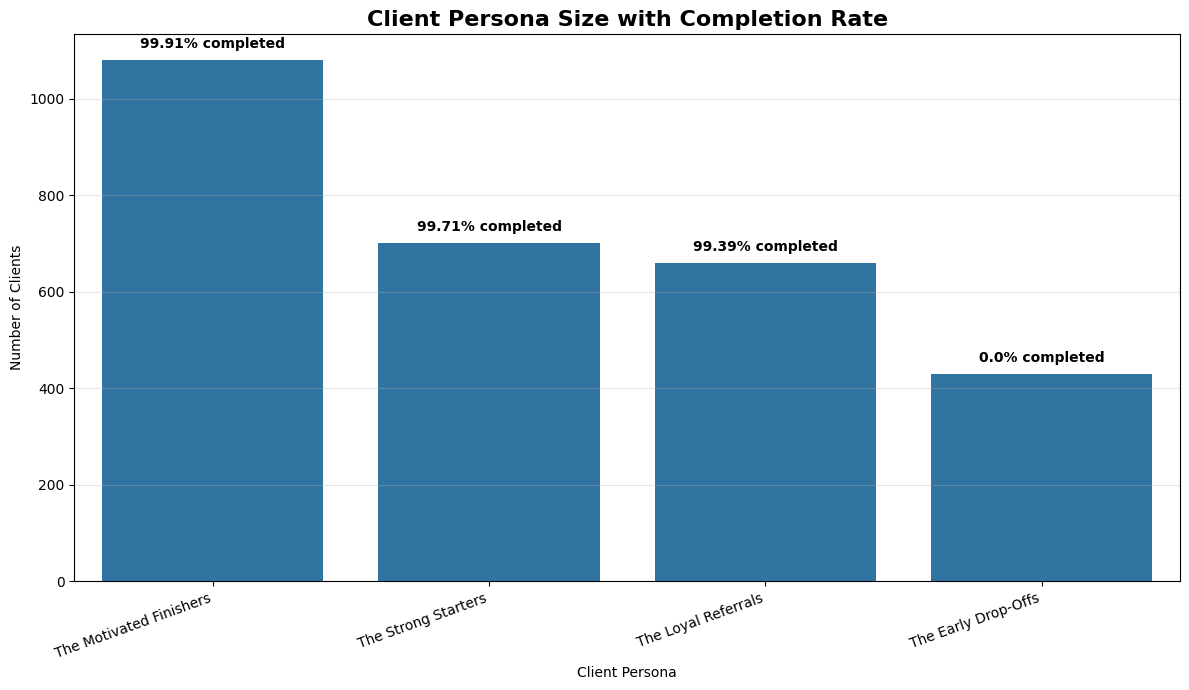

Persona size and completion rate chart saved successfully!
Saved to: ../06_visuals/phase4_segmentation


In [16]:
# ============================================================
# Phase 4 Part B
# Step 9: Bar Chart of Persona Size and Completion Rate
# ============================================================

# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ------------------------------------------------------------
# Prepare data for chart
# ------------------------------------------------------------

# Create a copy of the named cluster profile
bar_df = cluster_profile_named.copy()

# Sort personas by client count from largest to smallest
bar_df = bar_df.sort_values(by="Client_Count", ascending=False)

# ------------------------------------------------------------
# Create bar chart for persona size
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

# Create bar chart
ax = sns.barplot(
    data=bar_df,
    x="Persona",
    y="Client_Count"
)

# Add completion rate labels on top of each bar
for index, row in bar_df.iterrows():
    ax.text(
        x=list(bar_df["Persona"]).index(row["Persona"]),
        y=row["Client_Count"] + 25,
        s=f"{row['Completion_Rate']}% completed",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# Add chart title and labels
plt.title(
    "Client Persona Size with Completion Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Client Persona")
plt.ylabel("Number of Clients")

# Rotate x-axis labels for readability
plt.xticks(rotation=20, ha="right")

# Add light grid for readability
plt.grid(axis="y", alpha=0.3)

# Improve layout
plt.tight_layout()

# ------------------------------------------------------------
# Save chart
# ------------------------------------------------------------

output_folder = "../06_visuals/phase4_segmentation"
os.makedirs(output_folder, exist_ok=True)

plt.savefig(
    f"{output_folder}/persona_size_completion_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Persona size and completion rate chart saved successfully!")
print("Saved to:", output_folder)

In [17]:
# ============================================================
# Phase 4 Part B
# Step 10: Save Segmentation Dataset and Cluster Profile Tables
# ============================================================

# Import os to work with folders
import os

# ------------------------------------------------------------
# Create output folder
# ------------------------------------------------------------

# This folder will store Phase 4 segmentation outputs
output_folder = "../05_outputs/phase4_client_segmentation"

# Create the folder if it does not already exist
os.makedirs(output_folder, exist_ok=True)

# ------------------------------------------------------------
# Save full segmented client dataset
# ------------------------------------------------------------

# This saves all eligible clients used in clustering,
# including their assigned Cluster number and Persona name
seg_df_for_clustering.to_csv(
    f"{output_folder}/segmented_clients_with_personas.csv",
    index=False
)

# ------------------------------------------------------------
# Save named cluster profile table
# ------------------------------------------------------------

# This saves the summarized profile of each persona
cluster_profile_named.to_csv(
    f"{output_folder}/client_persona_profile_summary.csv",
    index=False
)

# ------------------------------------------------------------
# Save k results table
# ------------------------------------------------------------

# This saves the elbow and silhouette results from k = 2 to 10
k_results.to_csv(
    f"{output_folder}/kmeans_elbow_silhouette_results.csv",
    index=False
)

# ------------------------------------------------------------
# Save PCA dataframe
# ------------------------------------------------------------

# This saves PCA coordinates for each client for future visualization
pca_df.to_csv(
    f"{output_folder}/pca_client_persona_coordinates.csv",
    index=False
)

# ------------------------------------------------------------
# Confirm files were saved
# ------------------------------------------------------------

print("Client segmentation files saved successfully!")
print("Saved folder:", output_folder)

Client segmentation files saved successfully!
Saved folder: ../05_outputs/phase4_client_segmentation


In [18]:
# ============================================================
# Phase 4 Part C
# Step 1: Compare Referred vs Non-Referred Clients
# ============================================================

# Create a copy of the main dataframe for referral analysis
referral_df = df.copy()

# ------------------------------------------------------------
# Make sure Was_Referred exists
# ------------------------------------------------------------

# If Was_Referred does not exist, create it from Lead_Source
# Referral clients are those whose lead source is Referral
if "Was_Referred" not in referral_df.columns:
    referral_df["Was_Referred"] = np.where(
        referral_df["Lead_Source"] == "Referral",
        True,
        False
    )

# Create a clean label for readability
referral_df["Referral_Group"] = np.where(
    referral_df["Was_Referred"] == True,
    "Referred Clients",
    "Non-Referred Clients"
)

# ------------------------------------------------------------
# Create helper outcome flags
# ------------------------------------------------------------

# Completed program flag
referral_df["Completed_Flag"] = np.where(
    referral_df["Status"] == "Completed",
    1,
    0
)

# Goal achieved flag
referral_df["Goal_Achieved_Flag"] = np.where(
    referral_df["Goal_Achieved"] == "Yes",
    1,
    0
)

# Second round flag
referral_df["Second_Round_Flag"] = np.where(
    referral_df["Second_Round"] == "Yes",
    1,
    0
)

# ------------------------------------------------------------
# Did they refer someone else?
# ------------------------------------------------------------

# A client referred someone else if their Client_ID appears in the Referred_By column
# First, get all client IDs that appear as a referrer
referrer_ids = referral_df["Referred_By"].dropna().unique()

# Create flag for whether each client referred someone else
referral_df["Referred_Someone_Else_Flag"] = np.where(
    referral_df["Client_ID"].isin(referrer_ids),
    1,
    0
)

# ------------------------------------------------------------
# Create referred vs non-referred comparison table
# ------------------------------------------------------------

referral_comparison = (
    referral_df
    .groupby("Referral_Group")
    .agg(
        Client_Count=("Client_ID", "count"),
        Completion_Rate=("Completed_Flag", "mean"),
        Goal_Achievement_Rate=("Goal_Achieved_Flag", "mean"),
        Avg_Checkin_Rate_Pct=("Checkin_Rate_Pct", "mean"),
        Second_Round_Rate=("Second_Round_Flag", "mean"),
        Referred_Someone_Else_Rate=("Referred_Someone_Else_Flag", "mean")
    )
    .reset_index()
)

# Convert rate columns to percentages
rate_cols = [
    "Completion_Rate",
    "Goal_Achievement_Rate",
    "Second_Round_Rate",
    "Referred_Someone_Else_Rate"
]

for col in rate_cols:
    referral_comparison[col] = referral_comparison[col] * 100

# Round all values
referral_comparison = referral_comparison.round(2)

# Display comparison table
referral_comparison

,Referral_Group,Client_Count,Completion_Rate,Goal_Achievement_Rate,Avg_Checkin_Rate_Pct,Second_Round_Rate,Referred_Someone_Else_Rate
0,Non-Referred Clients,2228,79.71,50.72,73.95,6.91,22.58
1,Referred Clients,772,84.84,52.59,77.73,35.49,23.06


In [19]:
# ============================================================
# Phase 4 Part C
# Step 2: Calculate Referral Lift
# ============================================================

# ------------------------------------------------------------
# Separate referred and non-referred rows from the comparison table
# ------------------------------------------------------------

referred_row = referral_comparison[
    referral_comparison["Referral_Group"] == "Referred Clients"
].iloc[0]

non_referred_row = referral_comparison[
    referral_comparison["Referral_Group"] == "Non-Referred Clients"
].iloc[0]

# ------------------------------------------------------------
# Select metrics to compare
# ------------------------------------------------------------

referral_metrics = [
    "Completion_Rate",
    "Goal_Achievement_Rate",
    "Avg_Checkin_Rate_Pct",
    "Second_Round_Rate",
    "Referred_Someone_Else_Rate"
]

# Create empty list to store results
lift_results = []

# ------------------------------------------------------------
# Calculate difference and lift for each metric
# ------------------------------------------------------------

for metric in referral_metrics:
    
    referred_value = referred_row[metric]
    non_referred_value = non_referred_row[metric]
    
    # Difference in percentage points
    difference_points = referred_value - non_referred_value
    
    # Times more likely / lift ratio
    times_more_likely = (
        referred_value / non_referred_value
        if non_referred_value != 0
        else np.nan
    )
    
    # Percent lift
    percent_lift = (
        (difference_points / non_referred_value) * 100
        if non_referred_value != 0
        else np.nan
    )
    
    # Store the result
    lift_results.append({
        "Metric": metric,
        "Non_Referred_Value": non_referred_value,
        "Referred_Value": referred_value,
        "Difference_Points": difference_points,
        "Times_More_Likely": times_more_likely,
        "Percent_Lift": percent_lift
    })

# Convert results into dataframe
referral_lift = pd.DataFrame(lift_results)

# Round results
referral_lift = referral_lift.round(2)

# Display referral lift table
referral_lift

,Metric,Non_Referred_Value,Referred_Value,Difference_Points,Times_More_Likely,Percent_Lift
0,Completion_Rate,79.71,84.84,5.13,1.06,6.44
1,Goal_Achievement_Rate,50.72,52.59,1.87,1.04,3.69
2,Avg_Checkin_Rate_Pct,73.95,77.73,3.78,1.05,5.11
3,Second_Round_Rate,6.91,35.49,28.58,5.14,413.60
4,Referred_Someone_Else_Rate,22.58,23.06,0.48,1.02,2.13


In [22]:
# ============================================================
# Phase 4 Part C
# Step 3: Estimate Annual New Clients from Referral Program
# ============================================================

# ------------------------------------------------------------
# Create completed client flag
# ------------------------------------------------------------

referral_df["Completed_Flag"] = np.where(
    referral_df["Status"] == "Completed",
    1,
    0
)

# ------------------------------------------------------------
# Extract year from Payment_Date
# ------------------------------------------------------------

# Convert Payment_Date to datetime if it is not already datetime
referral_df["Payment_Date"] = pd.to_datetime(
    referral_df["Payment_Date"],
    errors="coerce",
    dayfirst=True
)

# Create payment year
referral_df["Payment_Year"] = referral_df["Payment_Date"].dt.year

# ------------------------------------------------------------
# Count completed clients by year
# ------------------------------------------------------------

completed_by_year = (
    referral_df
    .groupby("Payment_Year")
    .agg(
        Completed_Clients=("Completed_Flag", "sum")
    )
    .reset_index()
)

# ------------------------------------------------------------
# Estimate new referral clients
# ------------------------------------------------------------

# Assumption:
# Every completed client has a 10% chance of referring 1 new client
completed_by_year["Estimated_New_Referral_Clients"] = (
    completed_by_year["Completed_Clients"] * 0.10
).round(0).astype(int)

# ------------------------------------------------------------
# Calculate total estimate across all years
# ------------------------------------------------------------

total_completed_clients = referral_df["Completed_Flag"].sum()
estimated_total_new_referrals = round(total_completed_clients * 0.10)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("Total completed clients:", total_completed_clients)
print("Estimated new clients from 10% referral conversion:", estimated_total_new_referrals)

completed_by_year

Total completed clients: 2431
Estimated new clients from 10% referral conversion: 243


,Payment_Year,Completed_Clients,Estimated_New_Referral_Clients
0,2022,342,34
1,2023,799,80
2,2024,1290,129


In [23]:
# ============================================================
# Phase 4 Part C
# Step 5: Save Referral DNA Tables
# ============================================================

# Import os to work with folders
import os

# ------------------------------------------------------------
# Create output folder
# ------------------------------------------------------------

# This folder will store Phase 4 Referral DNA outputs
output_folder = "../05_outputs/phase4_referral_dna"

# Create the folder if it does not already exist
os.makedirs(output_folder, exist_ok=True)

# ------------------------------------------------------------
# Save referred vs non-referred comparison table
# ------------------------------------------------------------

referral_comparison.to_csv(
    f"{output_folder}/referred_vs_non_referred_comparison.csv",
    index=False
)

# ------------------------------------------------------------
# Save referral lift table
# ------------------------------------------------------------

referral_lift.to_csv(
    f"{output_folder}/referral_lift_analysis.csv",
    index=False
)

# ------------------------------------------------------------
# Save yearly referral opportunity table
# ------------------------------------------------------------

completed_by_year.to_csv(
    f"{output_folder}/estimated_new_referrals_by_year.csv",
    index=False
)

# ------------------------------------------------------------
# Save client-level referral dataset
# ------------------------------------------------------------

referral_df.to_csv(
    f"{output_folder}/client_level_referral_analysis.csv",
    index=False
)

# ------------------------------------------------------------
# Confirm files were saved
# ------------------------------------------------------------

print("Referral DNA files saved successfully!")
print("Saved folder:", output_folder)

Referral DNA files saved successfully!
Saved folder: ../05_outputs/phase4_referral_dna
